In [2]:
import pandas as pd

df = pd.read_csv("data/dataset.csv", encoding="utf-8")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13501 entries, 0 to 13500
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           13501 non-null  int64 
 1   Title                13496 non-null  object
 2   Ingredients          13501 non-null  object
 3   Instructions         13493 non-null  object
 4   Image_Name           13501 non-null  object
 5   Cleaned_Ingredients  13501 non-null  object
dtypes: int64(1), object(5)
memory usage: 633.0+ KB


# Preprocessing
Removing useless columns and rows with null values.
Removing also the corrisponding images to those rows.

In [3]:
import os

df.drop(columns=["Unnamed: 0"], inplace=True)
df_missing = df[df.isnull().any(axis=1)]
df.dropna(inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 13493 entries, 0 to 13500
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Title                13493 non-null  object
 1   Ingredients          13493 non-null  object
 2   Instructions         13493 non-null  object
 3   Image_Name           13493 non-null  object
 4   Cleaned_Ingredients  13493 non-null  object
dtypes: object(5)
memory usage: 632.5+ KB
None


In [4]:
# df.describe()

df = df[df['Image_Name'] != '#NAME?']
df = df[~df['Ingredients'].astype(str).isin(['[]', "['']"])]
df = df[~df['Cleaned_Ingredients'].astype(str).isin(['[]', "['']"])]
df = df.drop_duplicates(subset=['Title', 'Ingredients', 'Instructions'], keep='first')
print(f"Dimensioni finali del dataset: {df.shape}\n")
print(df.describe(include='O'))

Dimensioni finali del dataset: (13444, 5)

                Title                                        Ingredients  \
count           13444                                              13444   
unique          13267                                              13440   
top     Potato Latkes  ['1 cup (200 g) sugar', '3/4 cup (180 ml) wate...   
freq                5                                                  2   

                                             Instructions  \
count                                               13444   
unique                                              13428   
top     Place ingredients in blender in the order list...   
freq                                                    5   

                                               Image_Name  \
count                                               13444   
unique                                              13444   
top     miso-butter-roast-chicken-acorn-squash-panzanella   
freq                      

In [5]:
df.describe()

,Title,Ingredients,Instructions,Image_Name,Cleaned_Ingredients
count,13444,13444,13444,13444,13444
unique,13267,13440,13428,13444,13440
top,Potato Latkes,"['1 cup (200 g) sugar', '3/4 cup (180 ml) wate...",Place ingredients in blender in the order list...,miso-butter-roast-chicken-acorn-squash-panzanella,"['1 cup (200 g) sugar', '3/4 cup (180 ml) wate..."
freq,5,2,5,1,2


## Image cleaning 

In [6]:
if df_missing.shape[0] > 0:
    print(f"Trovate {df_missing.shape[0]} righe con valori mancanti.")
    print("Rimuovendo le immagini corrispondenti alle righe con valori mancanti...")

image_folder = os.path.join("data", "Food Images")

for index, row in df_missing.iterrows():
    img_name = str(row["Image_Name"])
    
    if not img_name.endswith(".jpg"):
        img_name += ".jpg"
        
    image_path = os.path.join(image_folder, img_name)
    
    if os.path.exists(image_path):
        print(f"Rimuovo {image_path}...")
        os.remove(image_path)
    else:
        print(f"Immagine non trovata al percorso: {image_path}")

Trovate 8 righe con valori mancanti.
Rimuovendo le immagini corrispondenti alle righe con valori mancanti...
Immagine non trovata al percorso: data/Food Images/broccolini-cheddar-gratin-with-rye-breadcrumbs-51255550.jpg
Immagine non trovata al percorso: data/Food Images/smoked-salmon-with-egg-salad-and-green-beans-350313.jpg
Immagine non trovata al percorso: data/Food Images/royal-icing-240751.jpg
Immagine non trovata al percorso: data/Food Images/roasted-game-hens-with-caramelized-root-vegetables-and-dried-currant-sauce-236880.jpg
Immagine non trovata al percorso: data/Food Images/chicken-soup-with-rice-232605.jpg
Immagine non trovata al percorso: data/Food Images/double-lemon-bars-232572.jpg
Immagine non trovata al percorso: data/Food Images/pear-and-frangipane-crostata-with-raspberry-vinegar-glaze-231327.jpg
Immagine non trovata al percorso: data/Food Images/hazelnut-shortbread-sticks-231311.jpg


## Text cleaning (Test)

In [7]:
# take random text from the dataset
import random
random_index = random.randint(0, len(df) - 1)
# print ingredients and instructions in an extended format
print(f"Ingredients:\n{df.iloc[random_index]['Ingredients']}\n")
print(f"Instructions:\n{df.iloc[random_index]['Instructions']}\n")

print("Esempi di titoli:")
for i in range(10):
    print(f"{i+1}. {df.iloc[i]['Title']}")

Ingredients:
['5 Tbsp. extra-virgin olive oil, divided', '2 bunches Swiss chard, ribs and stems removed and finely chopped, leaves coarsely chopped (keep separate)', '1 large shallot, thinly sliced', '1 (3-inch) piece ginger, peeled, thinly sliced lengthwise', 'Kosher salt', '½ tsp. ground turmeric', '1 (1½-lb.) skinless salmon fillet, preferably center cut', '3 garlic cloves, thinly sliced', '½ serrano chile, thinly sliced', '½ cup unsweetened coconut flakes', 'Freshly ground black pepper']

Instructions:
Preheat oven to 300°F. Heat 2 Tbsp. oil in a large ovenproof skillet over medium-high. Add Swiss chard ribs and stems, shallot, and ginger and cook, stirring occasionally, until shallot is softened but not browned, about 3 minutes. Add Swiss chard leaves and cook, stirring, until partly wilted, about 3 minutes. Remove from heat and season with salt.
Combine 2 Tbsp. oil and turmeric in a small bowl. Place salmon, skin side down, on top of greens in skillet. Season salmon with salt and

# Model - CLIP 
* We use the pre-trained CLIP model to convert all recipes titles into mathematical vectors (embeddings), then we process them in batches. 
* After generating and normalizing them, we concatenate the results into a single large tensor and save them to the recipe_embeddings.pt file. (precomputing)

In [8]:
import torch
from transformers import CLIPProcessor, CLIPModel
from tqdm.notebook import tqdm 
DEVICE =  "cpu"

model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id).to(DEVICE)
processor = CLIPProcessor.from_pretrained(model_id)

EMBEDDINGS_PATH = "data/recipe_embeddings.pt"

if os.path.exists(EMBEDDINGS_PATH):
    print(f"Embeddings già presenti in '{EMBEDDINGS_PATH}', caricamento...")
    saved_text_features = torch.load(EMBEDDINGS_PATH, map_location="cpu")
    print(f"Caricati {saved_text_features.shape[0]} vettori.")
else:
    titles = df["Title"].astype(str).tolist()
    batch_size = 128
    all_text_features = []

    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(titles), batch_size), desc="Calcolando embeddings"):
            batch_titles = titles[i:i+batch_size]
            
            inputs = processor(
                text=batch_titles,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=77,
            ).to(DEVICE)

            text_outputs  = model.text_model(**inputs) #norm
            text_features = model.text_projection(text_outputs.pooler_output)

            #text_features = model.get_text_features(**inputs).pooler_output  # estrai le features testuali 
            #text_features = model.text_projection(text_features)  # proietta nello spazio CLIP condiviso

            # normalizzazione
            import torch.nn.functional as F
            text_features = F.normalize(text_features, p=2, dim=-1)
            all_text_features.append(text_features.cpu())
        
    saved_text_features = torch.cat(all_text_features, dim=0)
    torch.save(saved_text_features, EMBEDDINGS_PATH)
    print(f"Fine. Salvati {saved_text_features.shape[0]} vettori in '{EMBEDDINGS_PATH}'")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Embeddings già presenti in 'data/recipe_embeddings.pt', caricamento...
Caricati 13444 vettori.


#### Description

* Given a food image path, returns the most similar recipe from the dataset.

* The image is encoded into a CLIP embedding and compared against all
pre-computed recipe title embeddings.
 
* It returns the best match as a dictionary object containing title, ingredients, instructions and
similarity score.

* Cosine similarity = measures the angle between two vectors

#### Association Image - Text (CLIP)

* The model is pre-trained to link an image with a corresponding text (description)
* When we submit a new image, it searches the closest result

* CLIP uses two separate encoders — one for images, one for text — that project
  inputs into a shared 512-dimensional vector space
* During training, matching (image, text) pairs are pushed close together while
  unrelated pairs are pushed apart 
* Recipe titles (from our DATASET) act as semantic labels: they are pre-encoded once and saved to disk.
  At inference time, only the image embedding is computed and compared against
  all pre-computed title embeddings via cosine similarity
* The recipe whose title vector is closest to the image vector is returned,
  along with its ingredients and instructions

Image => Clip produces the closest vector (descriptor) => Among the 13.000 embeddings (from our dataset) it takes the closest with the descriptor 

In [9]:
from PIL import Image
from torch.nn import functional as F

def identify_recipe(image_path: str) -> dict:
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)

    model.eval() 
    with torch.no_grad():
        vision_outputs  = model.vision_model(**inputs) # estrai le features visive
        image_features  = model.visual_projection(vision_outputs.pooler_output) # proietta nello spazio CLIP condiviso
        image_features  = F.normalize(image_features, p=2, dim=-1).cpu() 

    # Cosine similarity, cioè l'angolo tra i vettori 
    similarities = (saved_text_features @ image_features.T).squeeze(1) # si computa la similarità tra l'immagine e tutte le ricette testuali
    best_idx = similarities.argmax().item() # si trova l'indice della ricetta più simile

    row = df.iloc[best_idx]
    return {
        "title":        row["Title"],
        "ingredients":  row["Cleaned_Ingredients"],
        "instructions": row["Instructions"],
        "similarity":   round(similarities[best_idx].item(), 3),
    }

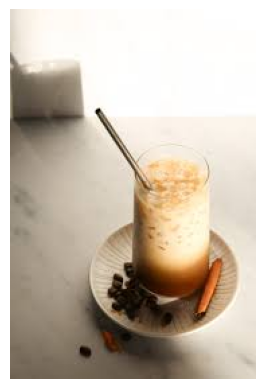

Piatto riconosciuto : Iced Coffee Shakerato
Similarity score   : 0.324

Ingredienti:
['1 1/2 ounces espresso or 3 ounces very strong coffee, cooled slightly', '1 tablespoon sweetened condensed milk', '1 1/2 teaspoons simple syrup']

Preparazione:
Combine espresso, sweetened condensed milk, and simple syrup in a cocktail shaker. Fill shaker with ice, cover, and shake vigorously until outside of shaker is very cold and mixture inside is very, very frothy, about 30 seconds.
Using a cocktail strainer or slotted spoon to hold back ice while allowing foam and some small ice chips to pass through, pour into an ice-filled glass.


In [10]:
# TEST

test_path = "data/TEST/iced_coffee.jpg"
result = identify_recipe(test_path)

from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(test_path)
plt.imshow(image)
plt.axis('off')
plt.show()

print(f"Piatto riconosciuto : {result['title']}")
print(f"Similarity score   : {result['similarity']}")
print(f"\nIngredienti:\n{result['ingredients']}")
print(f"\nPreparazione:\n{result['instructions']}")

## Image Embeddings (CLIP)

In [11]:
IMAGE_EMBEDDINGS_PATH = "data/image_embeddings.pt"

if os.path.exists(IMAGE_EMBEDDINGS_PATH):
    print(f"Image embeddings già presenti, caricamento...")
    saved_image_features = torch.load(IMAGE_EMBEDDINGS_PATH, map_location="cpu")
else:
    all_image_features = []
    missing = 0

    model.eval()
    with torch.no_grad():
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Encoding immagini"):
            img_path = os.path.join("data", "Food Images", row["Image_Name"] + ".jpg")

            if not os.path.exists(img_path):
                all_image_features.append(torch.zeros(1, 512))
                missing += 1
                continue

            image = Image.open(img_path).convert("RGB")
            inputs = processor(images=image, return_tensors="pt").to(DEVICE)

            vision_outputs = model.vision_model(**inputs)
            image_features = model.visual_projection(vision_outputs.pooler_output)
            image_features = F.normalize(image_features, p=2, dim=-1).cpu()
            all_image_features.append(image_features)

    saved_image_features = torch.cat(all_image_features, dim=0)
    torch.save(saved_image_features, IMAGE_EMBEDDINGS_PATH)
    print(f"Salvati {saved_image_features.shape[0]} vettori ({missing} immagini mancanti)")

assert saved_image_features.shape[0] == len(df)
print(f"Shape: {saved_image_features.shape}")

Image embeddings già presenti, caricamento...
Shape: torch.Size([13444, 512])


In [12]:
def identify_recipe_via_image(image_path: str) -> dict:
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)

    model.eval()
    with torch.no_grad():
        vision_outputs = model.vision_model(**inputs)
        image_features = model.visual_projection(vision_outputs.pooler_output)
        image_features = F.normalize(image_features, p=2, dim=-1).cpu()

    similarities = (saved_image_features @ image_features.T).squeeze(1)
    best_idx = similarities.argmax().item()

    row = df.iloc[best_idx]
    return {
        "title":        row["Title"],
        "ingredients":  row["Cleaned_Ingredients"],
        "instructions": row["Instructions"],
        "similarity":   round(similarities[best_idx].item(), 3),
    }

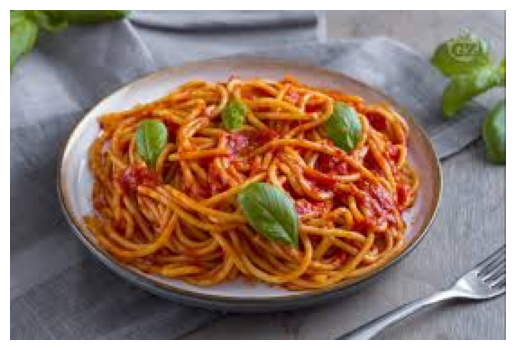

Hint testuale     : pasta with tomato
Peso testo        : 0.5
Piatto riconosciuto : Burst Cherry Tomato Pasta
Similarity score   : 0.873

Ingredienti:
['½ cup extra-virgin olive oil, plus more for drizzling', '6 garlic cloves, smashed', '2½ lb. cherry tomatoes (about 4 pints)', '2 large sprigs basil, plus 1 cup basil leaves, torn if large', '¾ tsp. crushed red pepper flakes', '1½ tsp. kosher salt, plus more', 'Pinch of sugar (optional)', '12 oz. casarecce or other medium-size pasta', '1 oz. Parmesan', 'finely grated (about ½ cup)', 'plus more for serving']

Preparazione:
Heat ½ cup oil in a large heavy pot over low. Add garlic and cook, stirring often with a wooden spoon, until softened but not browned, about 2 minutes.
Increase heat to medium and add tomatoes, basil sprigs, red pepper flakes, and 1½ tsp. salt. Cook, stirring to coat, until some of the tomatoes begin to burst and release their juices, about 4 minutes. Smash some but not all of the tomatoes with the spoon to help releas

In [23]:
# TEST SINGLE

test_path = "data/TEST/pastasugo_test.jpeg"

result = identify_recipe_via_image(test_path)

from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(test_path)
plt.imshow(image)
plt.axis('off')
plt.show()

print(f"Piatto riconosciuto : {result['title']}")
print(f"Similarity score   : {result['similarity']}")
print(f"\nIngredienti:\n{result['ingredients']}")
print(f"\nPreparazione:\n{result['instructions']}")


Immagine: pasta_al_pest.jpg


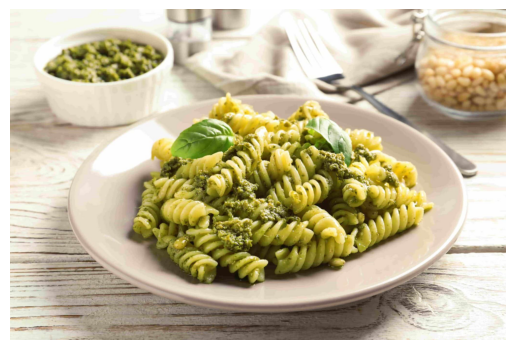

Piatto riconosciuto : Creamy Avocado Pesto
Similarity score    : 0.885

Ingredienti:
['1 ripe avocado, peeled, pitted, and diced', '1 cup (packed) fresh basil leaves', '1/3 cup pine nuts', '3 cloves garlic, chopped', 'Juice of 1 lemon', '2 tablespoons extra-virgin olive oil', 'Water as needed', 'Salt and pepper to taste']

Preparazione:
1. Combine avocado, basil, pine nuts, and garlic in a food processor or blender. With machine running, slowly stream in the lemon juice, olive oil, and water as needed to achieve a smooth pesto. Puree until completely blended and creamy.
2. Season with salt and pepper to taste.
3. Use immediately or keep, refrigerated, for up to four hours.

Immagine: fritto_misto.jpg


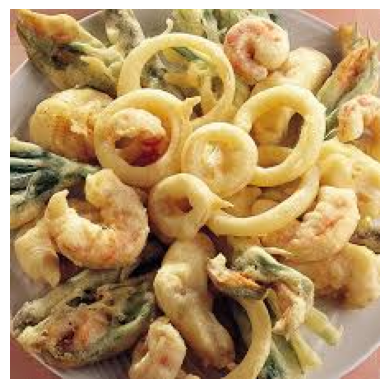

Piatto riconosciuto : Chile-Garlic Shrimp
Similarity score    : 0.801

Ingredienti:
['2 tablespoons extra-virgin olive oil (preferably Spanish)', '10 cloves garlic, thinly sliced', '2 pounds large shrimp, shelled and deveined', '2 dried red chiles (plus more for garnish, if desired)', '2 teaspoons brandy', '2 tablespoons chopped fresh parsley']

Preparazione:
Heat oil in a medium sauté pan over high heat. Sauté garlic until browned, about 2 minutes. Add shrimp and chiles; sauté until shrimp are cooked through, about 4 minutes. Add brandy and cook 1 minute more. Remove from heat. Transfer to a platter or divide equally among 8 small plates. Sprinkle with parsley, add salt to taste and serve.

Immagine: lasagna.jpg


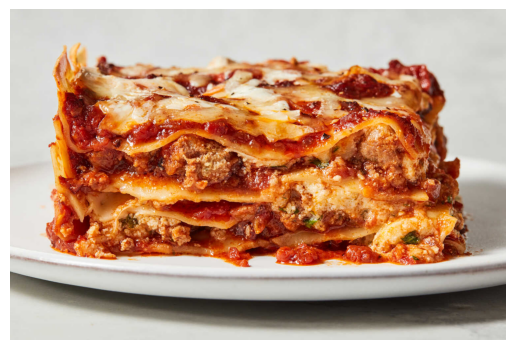

Piatto riconosciuto : Lasagna Bolognese
Similarity score    : 0.925

Ingredienti:
['1 large onion, coarsely chopped', '1 medium carrot, peeled, coarsely chopped', '1 celery stalk, coarsely chopped', '2 tablespoons olive oil', '1 pound ground beef chuck', '1 pound ground pork', '4 ounces pancetta (Italian bacon), finely chopped', 'Kosher salt, freshly ground pepper', '1 cup dry white wine', '1 cup whole milk', '1 14.5-ounce can crushed tomatoes', '3 cups low-sodium chicken broth, divided', '1/2 teaspoons kosher salt', '3 cups all-purpose flour, plus more', '4 large eggs, room temperature', '5 tablespoons unsalted butter', '1/4 cup all-purpose flour', '4 cups whole milk, warmed', 'Pinch of freshly ground nutmeg', 'Kosher salt', 'Kosher salt', 'Unsalted butter, room temperature (for dish)', '2 cups finely grated Parmesan', 'A pasta maker']

Preparazione:
Make the Bolognese sauce Pulse onion, carrot, and celery in a food processor until finely chopped.
Heat olive oil in a large heavy pot o

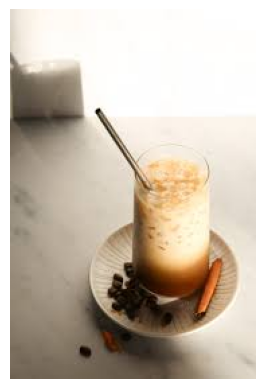

Piatto riconosciuto : Creamy Coffee Milkshake
Similarity score    : 0.872

Ingredienti:
['1 tablespoon grass-fed gelatin powder (can be bought online)', '1/2 cup organic canned coconut milk', '1 cup hot espresso', '1/2 teaspoon coconut crystals (optional)', 'A small pinch of sea salt', '1 cup espresso', '1 cup coconut milk', '1 tablespoon coconut butter', 'A pinch of vanilla powder', '4 protein cubes', '4 ice cubes']

Preparazione:
For the protein cubes, sprinkle the gelatin over the cold coconut milk and stir until the gelatin has dissolved and a paste has formed. Leave to rest for a few minutes, then pour the hot espresso on top and stir.
Add the coconut crystals (if using) and the salt, then pour the mixture into ice-cube trays. Freeze for 30 minutes to cool.
This makes more than enough protein cubes so you have extra for other days.
To make the milkshake, put all the ingredients into the blender and blend until combined. Serve.

Immagine: pizza_test.jpg


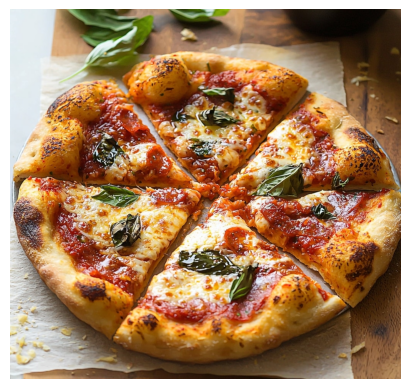

Piatto riconosciuto : Cauliflower-Crust Pizza with Tomatoes and Mozzarella
Similarity score    : 0.936

Ingredienti:
['1 small head of cauliflower (about 1 pound), coarsely chopped', '1 large egg, lightly beaten', '1 cup grated Parmesan (about 3 ounces)', '3/4 cup finely ground almond meal or almond flour', '1 garlic clove, finely chopped', '1/2 teaspoon dried Italian seasoning', '1/2 teaspoon kosher salt', '1/4 teaspoon freshly ground black pepper', '1 1/2 cups shredded part-skim mozzarella (about 5 ounces), divided', 'Vegetable oil (for brushing)', '1/2 cup marinara sauce', '1/4 cup basil leaves, torn', '1/2 teaspoon red pepper flakes (optional)', 'A pizza stone and peel', 'or 2 baking sheets']

Preparazione:
Arrange a rack in middle of oven; place pizza stone or inverted (if rimmed) baking sheet on rack. Preheat to 425°F.
Working in batches if needed, pulse cauliflower in a food processor fitted with the blade, or grate using the medium holes of a box grater, until fine crumbs form 

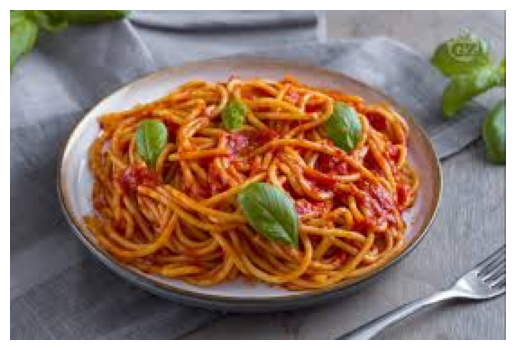

Piatto riconosciuto : My Mother's Butter, Tomato, and Onion Sauce
Similarity score    : 0.904

Ingredienti:
['2 pounds ripe tomatoes, or 3 cups canned whole peeled tomatoes with their juice', '1 medium sweet yellow onion', '5 tablespoons butter', '1 1/4 teaspoons salt']

Preparazione:
If using fresh tomatoes, peel them. Coarsely chop the fresh or canned tomatoes. Trim both ends of the onion; peel it and cut it in half lengthwise.
Put the tomatoes, onion, butter, and salt in a 4- to 5-quart saucepan over medium heat. When the tomatoes begin to bubble, lower the heat to a slow but steady simmer. Cook, stirring every 10 to 15 minutes, until the tomatoes are no longer watery and the sauce has reduced, about 45 minutes, depending on the size and shape of the pot. The sauce is done when the butter has separated from the tomatoes and there is no remaining liquid.


In [14]:
import os
from PIL import Image
import matplotlib.pyplot as plt

test_folder = "data/TEST/"

# scorri tutti i file nella cartella
for file_name in os.listdir(test_folder):

    file_path = os.path.join(test_folder, file_name)

    # opzionale: filtrare solo immagini
    if file_name.lower().endswith((".png", ".jpg", ".jpeg", ".webp")):

        print("\n==============================")
        print(f"Immagine: {file_name}")
        print("==============================")

        # riconoscimento ricetta
        result = identify_recipe_via_image(file_path)

        # mostra immagine
        image = Image.open(file_path)
        plt.imshow(image)
        plt.axis('off')
        plt.show()

        # stampa risultati
        print(f"Piatto riconosciuto : {result['title']}")
        print(f"Similarity score    : {result['similarity']}")
        print(f"\nIngredienti:\n{result['ingredients']}")
        print(f"\nPreparazione:\n{result['instructions']}")

#### Accuracy
* The image embedding approach has an higher score